# Pendulum trajectory prediction



## Problem definition

### Tasks

In this demo, we will:


*   Generate synthetic data
*   Train and evaluate a multilayer perceptron model
*   Train and evaluate a Physics-Informed Neural Network model


Reference: Seth 2023 : https://swarnadeepseth.github.io/pendulum_PINN.html   






### Import relevant modules

We will be manipulating Ordinary Differential Equations (ODEs) using *odeint*.

In [6]:
!pip install torch

import torch
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from PIL import Image

###

## ODE parameters and function


In [7]:
L = 0.025  # Length of pendulum
g = 9.81  # Acceleration due to gravity
w = np.sqrt(g/L)
k = w**2

end_time = 1

In [8]:
def simple_pendulum_eqn(state, t, L, g):
        theta, theta_dot = state
        theta_ddot = -k*np.sin(theta)
        return [theta_dot, theta_ddot]

## ODE simulation

In [10]:
initial_state = [np.pi/4, 0]

t = np.linspace(0, end_time, 500)
x = torch.tensor(t, dtype=torch.float32).view(-1, 1)

states = odeint(simple_pendulum_eqn, initial_state, t, args=(L, g))
y = torch.tensor(states[:, 0], dtype=torch.float32).view(-1, 1)
print(x.shape, y.shape)


torch.Size([500, 1]) torch.Size([500, 1])


In [11]:
# sample x, y
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)

torch.Size([10, 1]) torch.Size([10, 1])


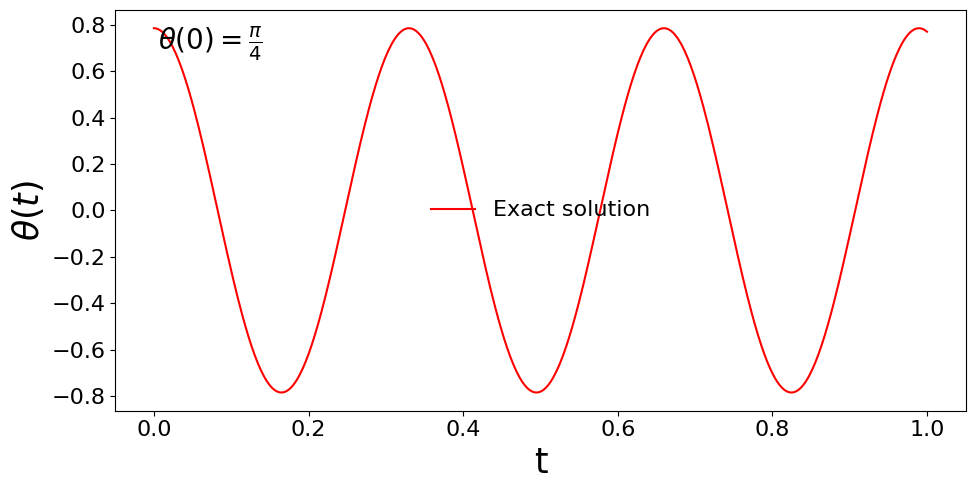

In [12]:
# View the analytical solution
fig = plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Exact solution', color='red')
plt.xlabel('t', fontsize=25)
plt.ylabel(r'$\theta(t)$', fontsize=25)
plt.tick_params(labelsize=16)
plt.legend(frameon=False, fontsize=16)

# annotate the initial condition in text
plt.text(0.05, 0.9, r'$\theta(0) = \frac{\pi}{4}$', fontsize=20, transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('solution.svg', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Traditional neural network model

### Build fully connected network

In [13]:
class FCN(torch.nn.Module):

        def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
            super().__init__()
            activation = torch.nn.Tanh
            self.fcs = torch.nn.Sequential(*[
                            torch.nn.Linear(N_INPUT, N_HIDDEN),
                            activation()])
            self.fch = torch.nn.Sequential(*[
                            torch.nn.Sequential(*[
                                torch.nn.Linear(N_HIDDEN, N_HIDDEN),
                                activation()]) for _ in range(N_LAYERS-1)])
            self.fce = torch.nn.Linear(N_HIDDEN, N_OUTPUT)

        def forward(self, x):
            x = self.fcs(x)
            x = self.fch(x)
            x = self.fce(x)
            return x

In [14]:
torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

### Train FCN

In [15]:
for i in range(1000):
  optimizer.zero_grad()
  yh = model(x_data)
  loss = torch.mean((yh-y_data)**2)# use mean squared error
  loss.backward()
  optimizer.step()



### Plot results

In [16]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="tab:green", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, end_time+0.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")

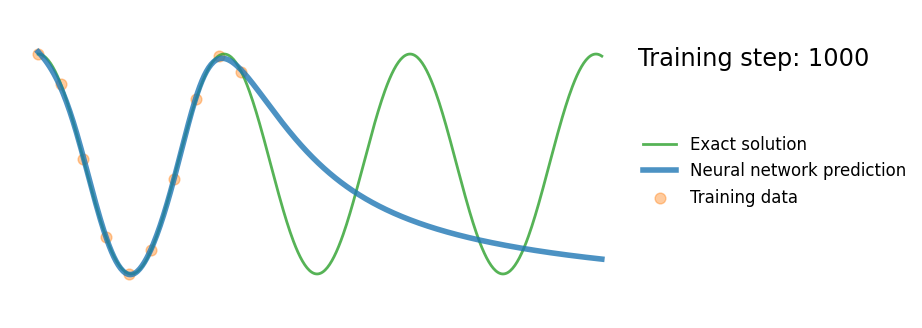

In [18]:
yh = model(x).detach()
plot_result(x, y, x_data, y_data, yh)

##

## Physics-Informed Neural Network

###

### Update training loop to include physics loss

In [19]:
x_physics = torch.linspace(0,end_time,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain

model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)


for i in range(20000):
    optimizer.zero_grad()

    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error

    # compute the "physics loss" - requires automatic differentiation
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + k*torch.sin(yhp)
    loss2 = (1e-4)*torch.mean(physics**2)

    # backpropagate joint loss
    loss = loss1 + loss2  # add two loss terms together
    loss.backward()
    optimizer.step()




### Plot results

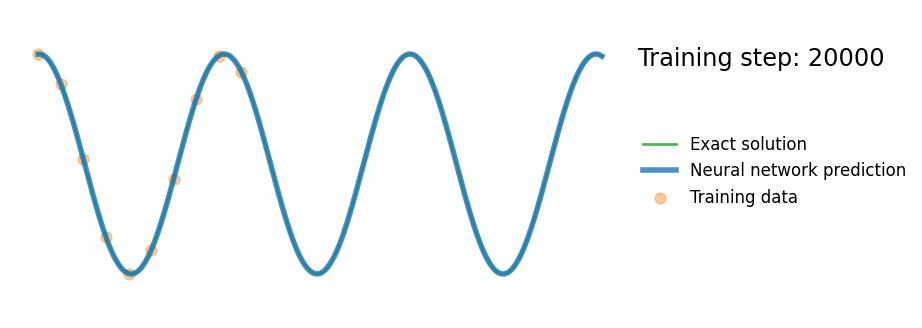

In [20]:
yh = model(x).detach()
xp = x_physics.detach()

plot_result(x,y,x_data,y_data,yh,xp)